In [1]:
from tslearn.clustering import TimeSeriesKMeans
import pandas as pd
import numpy as np
import sklearn.preprocessing
import matplotlib.pyplot as plt

from modules import ForecastingModel
from modules import YfScrapper

In [2]:
model = ForecastingModel(
    price_type="Close",
    time_period="5y",
    time_interval="1wk"
)

# Input file with a list of portfolio tickers
input_tickers = pd.read_csv('portfolio_tickers.csv')  
tickers = input_tickers['Tickers'].tolist()

In [4]:
df_list = []
for ticker in tickers:
    data = model.get_stock_price(ticker)
    df_list.append(data)
    
X_train = pd.concat(df_list, axis=1)
X_train = sklearn.preprocessing.scale(X_train)
X_train = X_train.T
X_train.shape

(37, 262)

In [5]:
N_CLUSTERS = 4

ts_kmeans_model = TimeSeriesKMeans(
    n_clusters=N_CLUSTERS,
    metric="dtw",
    max_iter=10,
    random_state=42
)
labels = ts_kmeans_model.fit_predict(X_train)
labels

array([2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 0, 2, 0, 0, 2, 0, 0, 0, 0,
       0, 0, 2, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2])

In [6]:
input_tickers['cluster'] = labels
input_tickers.groupby('cluster').count()

,Tickers
cluster,
0,20
2,17


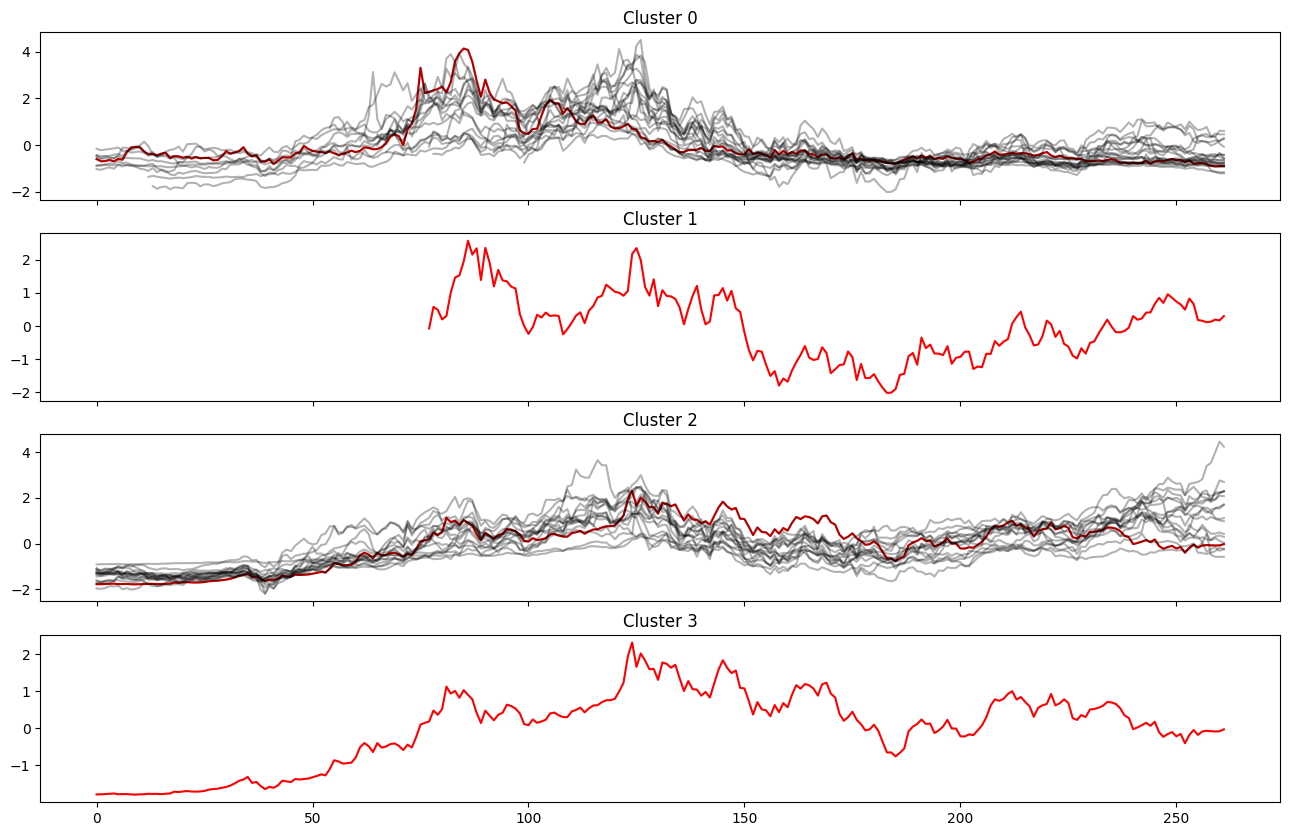

In [7]:
fig, axes = plt.subplots(
    nrows=N_CLUSTERS,
    ncols=1,
    figsize=(16, 10),
    sharex=True
)
for idx, cluster in enumerate(ts_kmeans_model.cluster_centers_):
    axes[idx].set_title(f"Cluster {idx}")
    axes[idx].plot(cluster, c='red')
    for ticker_series in X_train[np.where(labels==idx)]:
        axes[idx].plot(
            ticker_series, 
            c='black',
            alpha=0.3
        )